### Bước 1: Nhập và tiền xử lý ảnh

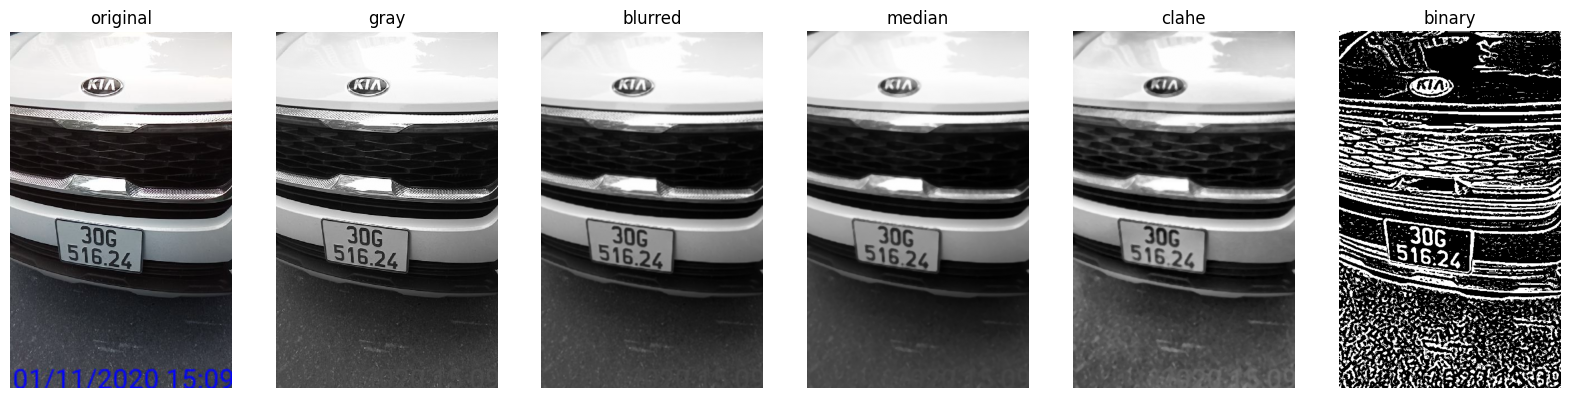

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Hàm để hiển thị hình ảnh
def display_image(images, titles):
    plt.figure(figsize=(20,10))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()
def load_and_preprocess(image_path):
    # 1. Tải ảnh
    original_image = cv2.imread(image_path)
    if original_image is None:
        print("Lỗi: Không thể tải ảnh.")
    else:
        # 2. Tiền xử lý 
        # Chuyển đổi sang ảnh xám
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        # Gaussian Blur để giảm nhiễu
        blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
        # Median Filter để giảm nhiễu nhiều hơn
        median_image = cv2.medianBlur(blurred_image, 5)
        # CLAHE để tăng cường độ tương phản
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        clahe_image = clahe.apply(median_image)
        # Binarization để phát hiện contours
        binary_image = cv2.adaptiveThreshold(
            clahe_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 11, 2
        )
        # 3. Trả về một dictionary để dễ dàng truy cập các bước
        return {
            "original": original_image,
            "gray": gray_image,
            "blurred": blurred_image,
            "median": median_image,
            "clahe": clahe_image,
            "binary": binary_image
        }
# Test 
image_path = r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-11-1-15-93yek_xsMxg.jpg'
process_images = load_and_preprocess(image_path)
if process_images:
    display_image(list(process_images.values()), list(process_images.keys()))

--- Gỡ lỗi Contours (Top 5 lớn nhất) ---
Contour 1: Area=10145, Aspect Ratio=1.65

✓✓✓ Số lượng biển số phát hiện: 1


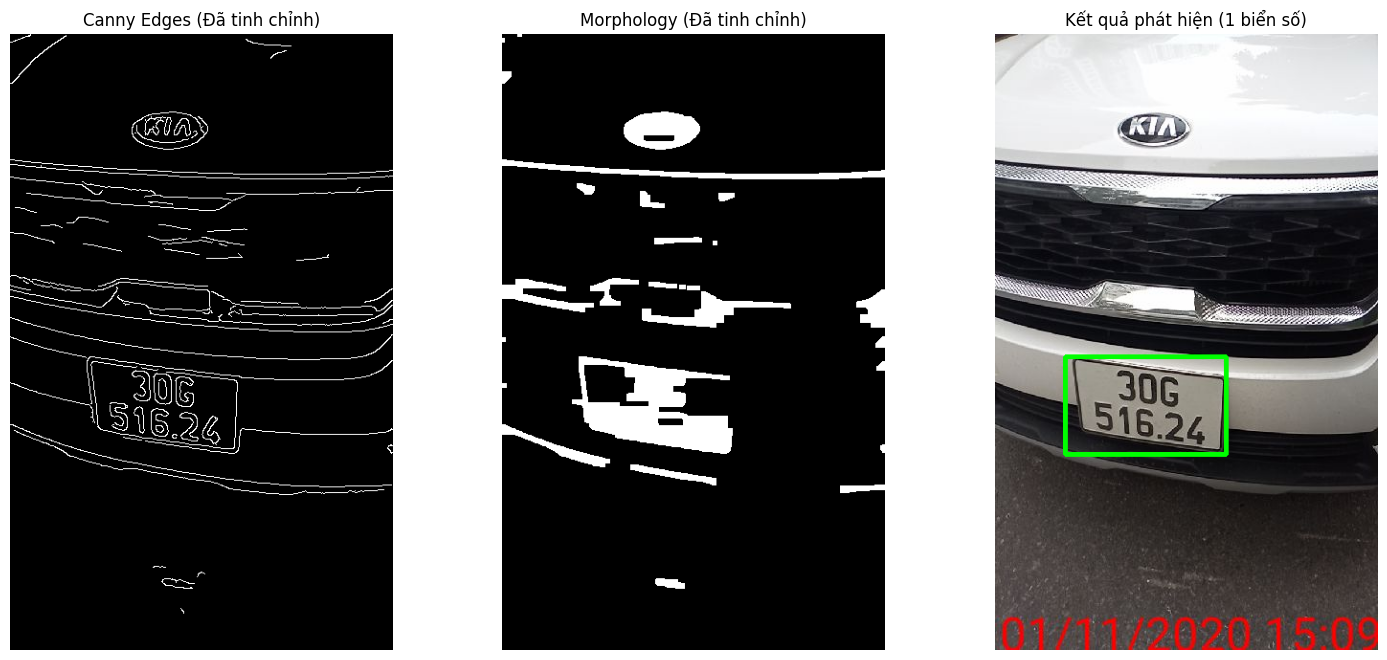

In [38]:
clahe_img = process_images['clahe']

# --- 1. Tinh chỉnh tham số ---
# Giảm ngưỡng Canny để bắt được nhiều cạnh hơn
edges = cv2.Canny(clahe_img, 100, 200) 

# Giảm kích thước kernel để tránh nối biển số với các phần khác của xe
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close) 

# Giữ nguyên kernel OPEN để xóa nhiễu
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)

# --- 2. Tìm và gỡ lỗi Contours ---
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Tạo ảnh copy để vẽ gỡ lỗi
debug_image = cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB)

print("--- Gỡ lỗi Contours (Top 5 lớn nhất) ---")
# Sắp xếp contours theo diện tích giảm dần và kiểm tra 5 cái lớn nhất
for i, contour in enumerate(sorted(contours, key=cv2.contourArea, reverse=True)[:1]):
    x, y, w, h = cv2.boundingRect(contour)
    area = cv2.contourArea(contour)
    aspect_ratio = w / h if h > 0 else 0
    print(f"Contour {i+1}: Area={area:.0f}, Aspect Ratio={aspect_ratio:.2f}")
    # Vẽ tất cả các contour được xét bằng màu xanh dương để xem
    cv2.rectangle(debug_image, (x, y), (x+w, y+h), (0, 0, 255), 2)


# --- 3. Lọc Contours với tham số mới ---
plates = []
# Thêm giới hạn diện tích tối đa để loại bỏ các vùng quá lớn
min_area = 5000
max_area = 12000
aspect_ratio_range = (1.0, 2.5) # Nới lỏng tỷ lệ một chút

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    area = cv2.contourArea(contour)
    aspect_ratio = w / h if h > 0 else 0
    if (min_area <= area and 
        aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
        plates.append((x, y, w, h))
        # Vẽ contour đạt chuẩn bằng màu xanh lá
        cv2.rectangle(debug_image, (x, y), (x+w, y+h), (0, 255, 0), 3)

print(f"\n✓✓✓ Số lượng biển số phát hiện: {len(plates)}")

# --- 4. Hiển thị kết quả ---
plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges (Đã tinh chỉnh)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(morph, cmap='gray')
plt.title('Morphology (Đã tinh chỉnh)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(debug_image)
plt.title(f'Kết quả phát hiện ({len(plates)} biển số)')
plt.axis('off')

plt.show()

### Bước 2: Phát hiện biển số xe bằng Canny Edge và Morphology

✓ Phát hiện 1 vùng biển số
  Plate 1: vị trí=(73, 337), kích thước=(168x102), tỷ lệ=1.65


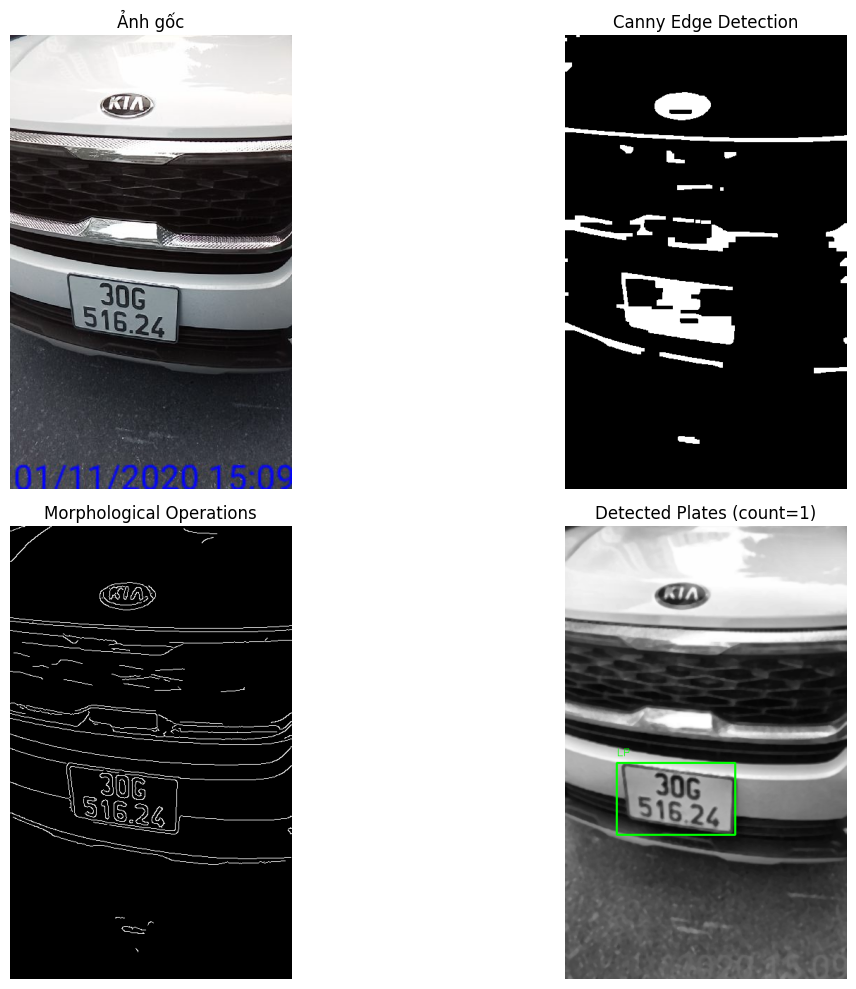

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_license_plate(image_preprocessed, canny_threshold1 = 100, canny_threshold2 = 200, 
                         min_area = 5000, aspect_ratio_range = (1.0, 2.5)):
    # 1. Phát hiện cạnh sử dụng Canny
    edges = cv2.Canny(image_preprocessed, canny_threshold1, canny_threshold2)
    
    # 2. Sử dụng Morphology để đóng các khoảng trống (phép đóng để nối các cạnh thành vùng liên tục)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    
    # 3. Phép mở để loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # 4. Tìm contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Lọc contours dựa trên diện tích và tỷ lệ khung hình
    plates = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # kiểm tra điều kiện diện tích và tỷ lệ khung hình
        if (area >= min_area and 
            aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            plates.append((x, y, w, h))
    return plates, morph, edges

# Test
detected_plates, edges_img, morph_img = detect_license_plate(process_images['clahe'])

print(f"✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# Visualize kết quả
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ảnh gốc
axes[0, 0].imshow(process_images['original'], cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Ảnh Canny edges
axes[0, 1].imshow(edges_img, cmap='gray')
axes[0, 1].set_title('Canny Edge Detection')
axes[0, 1].axis('off')

# Ảnh sau morphology
axes[1, 0].imshow(morph_img, cmap='gray')
axes[1, 0].set_title('Morphological Operations')
axes[1, 0].axis('off')

# Ảnh gốc với bounding boxes
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in detected_plates:
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()